# Task 3: Multi-Track Generalization with SB3 PPO

Trains the same two-phase PPO agent as `task2_laning_overtaking_sb3_ppo.ipynb`, but with `config["track"] = "random"`: **every episode resamples one of the five tracks** (fast, oval, stadium, rect, chicane — see the Track Shapes section below), so the policy must learn reactive lane-following instead of memorizing one circuit. The ego cannot observe its global position (its x/y features are ego-relative), which is what makes this work.

Differences vs the task2 notebook:
- phase 1 / phase 2 / eval configs use `"track": "random"`
- phase 1 budget is 1.5M steps (5 tracks need more coverage than 1)
- a **Generalization Report** section at the end evaluates the best model on every track separately

Empirical context (measured on this env): a policy trained on the fast track alone already zero-shot transfers to the four simpler tracks at the speed limit — random-track training additionally covers the tighter chicane kink and guards against regressions when track geometry changes.


In [2]:
# If this notebook is running in a fresh environment, install the core packages first.
# In the local repo environment you can usually leave this cell commented out.
#
# %pip install "highway-env>=1.8" "stable-baselines3[extra]>=2.0" tensorboard moviepy

from pathlib import Path
from copy import deepcopy
import base64
import os
import random

import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import highway_env  # Registers highway-env environments in many versions.
import numpy as np
import torch.nn as nn
import torch

from IPython.display import HTML, display
from stable_baselines3 import PPO
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback, EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecEnv

# Newer gymnasium versions can register an external environment package explicitly.
# Older highway-env versions register on import, so we keep this tolerant.
try:
    gym.register_envs(highway_env)
except Exception:
    pass


## Experiment Config

Task 2 is represented by `other_vehicles=3`. The notebook now starts from `RacetrackEnvOval.default_config()` and overrides only the pieces that define this experiment, so future highway-env API changes are easier to absorb.

In [3]:
SEED = 42
ENV_ID = "racetrack-v0"

# FULL multi-track training is the default in this notebook. For an
# end-to-end smoke test, set FAST_DEV_RUN=1 in the process environment
# before starting Jupyter.
FAST_DEV_RUN = False
USE_EARLY_STOP = False  # Stop training early if the evaluation reward is consistently high.

# Prefer CPU in notebooks unless a CUDA-enabled GPU is available and stable.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

EXP_ID = "sb3_ppo_gen_cnn"
if FAST_DEV_RUN:
    EXP_ID += "_fast"

WORK_DIR = Path.cwd()

RUN_DIR = WORK_DIR / "runs" / EXP_ID
MODEL_DIR = RUN_DIR / "models"
BEST_MODEL_DIR = MODEL_DIR / "best"
CHECKPOINT_DIR = MODEL_DIR / "checkpoints"
LOG_DIR = RUN_DIR / "logs"
VIDEO_DIR = RUN_DIR / "videos"
TB_LOG_DIR = RUN_DIR / "tensorboard"

for directory in [MODEL_DIR, BEST_MODEL_DIR, CHECKPOINT_DIR, LOG_DIR, VIDEO_DIR, TB_LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Reproducibility: exact runs can still vary across machines/GPU kernels.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Using device: cuda


In [4]:
def set_global_seeds(seed: int, fast_training: bool = True):
    """
    Seed every random source that affects training.
    Call this ONCE before creating envs or model.
    """
    random.seed(seed)                          # Python stdlib
    np.random.seed(seed)                       # NumPy
    torch.manual_seed(seed)                    # PyTorch CPU ops
    torch.cuda.manual_seed_all(seed)           # PyTorch GPU ops (all devices)
    os.environ["PYTHONHASHSEED"] = str(seed)   # Python hash randomisation

    # Optional: sacrifice speed for full CUDA determinism.
    # Comment out if training speed matters more than exact reproducibility.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False  # benchmark=True auto-tunes kernels
                                                 # but picks different ops each run
    if fast_training:
        # Let cuDNN find the fastest algorithm for your fixed input shapes.
        # One-time profiling cost of ~2-3 seconds at the start of training.
        # Not reproducible: two runs may produce slightly different loss curves
        # but converge to the same policy quality.
        torch.backends.cudnn.benchmark     = True
        torch.backends.cudnn.deterministic = False
    else:
        # Force deterministic algorithms throughout.
        # Reproducible: two runs with the same seed produce byte-identical results.
        # Costs 5-30% training speed depending on your CNN architecture.
        torch.backends.cudnn.benchmark     = False
        torch.backends.cudnn.deterministic = True

set_global_seeds(SEED, fast_training=not FAST_DEV_RUN)

In [5]:
from highway_env.envs import racetrack_env
from race_env import RacetrackFast
racetrack_env.RacetrackFast = RacetrackFast
gym.register(id=ENV_ID, entry_point="race_env:RacetrackFast")

c:\Users\16469\anaconda3\envs\circuit\lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment racetrack-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


## Track Shapes

All tracks available via `config["track"]` (and sampled by `"random"` during generalization training). Black lines are the corridor's outer edges — the physical walls; the light line between them is the lane divider (not a wall). Red letters mark checkpoint segment starts.


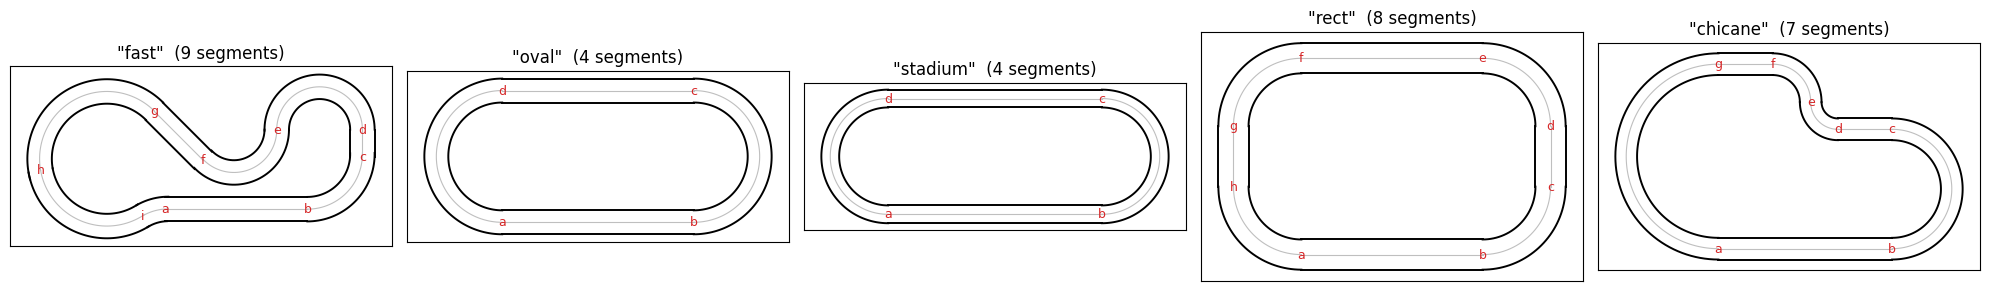

In [6]:
import matplotlib.pyplot as plt

TRACK_NAMES = ["fast", "oval", "stadium", "rect", "chicane"]

fig, axes = plt.subplots(1, len(TRACK_NAMES), figsize=(4 * len(TRACK_NAMES), 4))
for ax, name in zip(axes, TRACK_NAMES):
    tenv = gym.make(ENV_ID, config={"track": name}).unwrapped
    tenv.reset(seed=0)
    graph = tenv.road.network.graph
    for _from in graph:
        for _to in graph[_from]:
            lanes = graph[_from][_to]
            for k, lane in enumerate(lanes):
                s = np.linspace(0, lane.length, max(2, int(lane.length)))
                # corridor outer edges (the walls) in black, divider in grey
                edges = []
                if k == 0:
                    edges.append((-lane.width / 2, "k", 1.4))
                    edges.append((+lane.width / 2, "0.75", 0.8))   # divider
                if k == len(lanes) - 1:
                    edges.append((+lane.width / 2, "k", 1.4))
                for lat, color, lw in edges:
                    pts = np.array([lane.position(si, lat) for si in s])
                    ax.plot(pts[:, 0], pts[:, 1], color=color, lw=lw)
    seq = tenv.segment_sequence
    for i, seg in enumerate(seq):
        lane0 = tenv.road.network.get_lane((seg, seq[(i + 1) % len(seq)], 0))
        ax.annotate(seg, lane0.position(0, 2.5), fontsize=9,
                    color="tab:red", ha="center", va="center")
    ax.set_title(f'"{name}"  ({len(seq)} segments)')
    ax.set_aspect("equal")
    ax.invert_yaxis()   # match the env's screen orientation (y points down)
    ax.set_xticks([]); ax.set_yticks([])
    tenv.close()
plt.tight_layout()
plt.show()


In [7]:
N_ENVS = min(8, max(1, os.cpu_count() or 1))

# ════════════════════════════════════════════════════════════════════
# Speed and step count optimisation
#
# NOTE on eval_freq units: EvalCallback counts PER-ENV steps, so the
# interval in timesteps is eval_freq × N_ENVS. It must divide the phase
# budget at least once or no best_model.zip is ever written (this is
# exactly what happened in phase 2 before: 2048 × 8 = 16,384 > 8,192).
# ════════════════════════════════════════════════════════════════════

if FAST_DEV_RUN:
    # Quick run that still reaches VISIBLE LANING — checkpoints and lap
    # bonuses, not just forward driving. Measured on this env: with the
    # production hyperparameters (ent 0.02, lr 2e-4, batch 256), lap
    # competence emerges between 50k and 100k steps, so 120k phase-1
    # steps is the smallest budget that reliably laps. Smaller budgets
    # or higher entropy only ever show wall-to-wall wandering.
    PHASE1_TIMESTEPS = 150_000
    PHASE2_TIMESTEPS = 16_384
    P1_N_STEPS    = 512;  P2_N_STEPS    = 512
    P1_BATCH_SIZE = 256;  P2_BATCH_SIZE = 256
    P1_N_EPOCHS   =   8;  P2_N_EPOCHS   =   8
    P1_ENT_COEF   = 0.02; P2_ENT_COEF   = 0.005
    P1_LR         = 2e-4; P2_LR         = 1e-4
    # every 512×4×8 = 16,384 timesteps → ~7 evals in P1, 1 in P2
    P1_EVAL_FREQ  = P1_N_STEPS * 4
    P2_EVAL_FREQ  = P2_N_STEPS * 2
    CHECKPOINT_FREQ = 8192

else:
    # Reduced steps — sufficient with dense rewards + fast sim
    PHASE1_TIMESTEPS = 1_500_000   # 5 tracks need more coverage than 1
    PHASE2_TIMESTEPS = 3_000_000   # was 6_000_000

    # Shorter rollout = more frequent updates per wall-clock minute
    P1_N_STEPS    = 512
    P1_BATCH_SIZE = 256
    P1_N_EPOCHS   =  15
    P1_ENT_COEF   = 0.02
    P1_LR         = 2e-4    # slightly higher → faster convergence in phase 1

    P2_N_STEPS    = 1024    # was 2048 — more frequent updates
    P2_BATCH_SIZE = 256
    P2_N_EPOCHS   =  15
    P2_ENT_COEF   = 0.005
    P2_LR         = 1e-4

    # every 512×8×8 = 32,768 timesteps → ~30 evals over phase 1
    P1_EVAL_FREQ  = P1_N_STEPS * 8
    # every 1024×8×8 = 65,536 timesteps → ~45 evals over phase 2
    P2_EVAL_FREQ  = P2_N_STEPS * 8

    CHECKPOINT_FREQ = P2_N_STEPS * 20  # every 20 rollouts

# Slightly smaller clip range helps learning stay stable when the action space grows.
CLIP_RANGE = 0.15

# Stronger discounting and GAE smoothing can improve horizon-aware lane-following and overtaking behavior.
GAMMA = 0.99
GAE_LAMBDA = 0.98
MAX_GRAD_NORM = 0.5


## Build Training and Evaluation Environments

SB3 trains on vectorized environments. `DummyVecEnv` is the safest default inside notebooks on Windows. For longer command-line runs, set `USE_SUBPROC = True`.

In [8]:
class EnvFactory:
    """
    Picklable factory with explicit render_mode control.
    render_mode is always None during training.
    Pass render_mode="rgb_array" only for recording envs.
    """
    def __init__(self, config: dict, render_mode: str | None = None):
        self.config      = config
        self.render_mode = render_mode   # None during training, always

    def __call__(self) -> gym.Env:
        return gym.make(
            ENV_ID,
            config      = self.config,
            render_mode = self.render_mode,  # explicitly passed, never hardcoded
        )

In [9]:
# Training uses "random": the track (fast/oval/stadium/rect/chicane) is
# resampled EVERY EPISODE, so the policy must learn reactive lane-following
# instead of memorizing one layout. With 8 parallel envs every rollout
# already mixes several different circuits.
phase1_config = RacetrackFast.default_config().copy()
phase1_config["other_vehicles"] = 0
phase1_config["track"] = "random"

# Phase 2: add NPCs for avoidance
phase2_config = RacetrackFast.default_config().copy()
phase2_config["other_vehicles"] = 1
phase2_config["track"] = "random"

# Evaluation covers ALL five tracks: make_fresh_eval_env builds one sub-env
# per fixed track, and EvalCallback runs one deterministic episode on each.
# Best-model selection therefore averages over every circuit — a model that
# only masters some tracks can never look "best". Random-track eval, by
# contrast, is noisy AND can luck into easy draws.
# Eval episodes are short (120 s vs the 800 s training duration) so the
# five-track sweep stays cheap enough to run every few rollouts.
EVAL_TRACKS = ["fast", "oval", "stadium", "rect", "chicane"]
eval_config = RacetrackFast.default_config().copy()
eval_config["other_vehicles"] = 0
eval_config["terminate_off_road"] = True
eval_config["duration"] = 120


### Reward yardstick

Translates `eval/mean_reward` into laps: a lap has a concrete, computable value, so you can tell from TensorBoard alone whether the policy laps, loiters, or crashes early.


In [10]:
# What is a lap worth? Judge training progress against these numbers.
probe = gym.make(ENV_ID, config=eval_config).unwrapped
probe.reset(seed=0)
seq = probe.segment_sequence
lap_m = sum(probe.road.network.get_lane((a, b, 0)).length
            for a, b in zip(seq, seq[1:] + seq[:1]))
v_max = eval_config["speed_limit"]
steps_per_lap = lap_m / v_max * eval_config["policy_frequency"]
r_drive = 0.93   # measured per-step reward while lapping at the speed limit
r_idle  = 0.53   # measured per-step reward of a policy that just idles
ep_steps = eval_config["duration"] * eval_config["policy_frequency"]
print(f"track '{probe.active_track}': lap ≈ {lap_m:.0f} m ≈ {steps_per_lap:.0f} steps at {v_max:.0f} m/s")
print(f"return per lap        ≈ {steps_per_lap * r_drive:.0f}")
print(f"full-episode ceiling  ≈ {ep_steps * r_drive:.0f}   ({ep_steps:.0f} steps of clean driving)")
print(f"idle/loiter plateau   ≈ {ep_steps * r_idle:.0f}   (policy alive but not driving)")
print(f"early-termination     ≪ {ep_steps * r_idle:.0f}   (crashes/wall-stuck cut the episode)")
print()
print("Reading eval/mean_reward during training:")
print(f"  stuck near {ep_steps * r_idle:.0f} → loitering local optimum, not a step-budget problem")
print(f"  climbing past {ep_steps * r_idle:.0f} toward {ep_steps * r_drive:.0f} → lapping has emerged")
probe.close()


track 'fast': lap ≈ 349 m ≈ 109 steps at 16 m/s
return per lap        ≈ 101
full-episode ceiling  ≈ 558   (600 steps of clean driving)
idle/loiter plateau   ≈ 318   (policy alive but not driving)
early-termination     ≪ 318   (crashes/wall-stuck cut the episode)

Reading eval/mean_reward during training:
  stuck near 318 → loitering local optimum, not a step-budget problem
  climbing past 318 toward 558 → lapping has emerged


In [11]:
def make_fresh_eval_env(seed: int) -> VecEnv:
    """
    Fresh evaluation VecEnv with one sub-env per track in EVAL_TRACKS.
    With n_eval_episodes = len(EVAL_TRACKS), EvalCallback runs exactly one
    deterministic episode on every circuit and averages the returns.
    Never reuse an eval_env across phases — stale episode state causes
    EvalCallback to get inconsistent rewards.
    """
    factories = []
    for track in EVAL_TRACKS:
        cfg = dict(eval_config)   # picks up later eval_config edits (phase 2 NPCs)
        cfg["track"] = track
        factories.append(EnvFactory(cfg, render_mode=None))
    env = DummyVecEnv([(lambda f=f: Monitor(f())) for f in factories])
    env.seed(seed)
    return env


In [12]:
phase1_train_env = make_vec_env(
    EnvFactory(phase1_config, render_mode=None),
    n_envs      = N_ENVS,
    seed        = SEED,
    vec_env_cls = DummyVecEnv,
)

phase2_train_env = make_vec_env(
    EnvFactory(phase2_config, render_mode=None),
    n_envs      = N_ENVS,
    seed        = SEED,
    vec_env_cls = DummyVecEnv,
)

## Define PPO

The PPO policy uses a 3-layer actor and critic MLP, matching the spirit of `--arch Identity --fc_layers 3` from the older code: flatten the occupancy grid, then learn dense policy/value heads. Comments below explain every model setting that differs from SB3 defaults or maps to the older command.

In [13]:
class RacetrackCNN(BaseFeaturesExtractor):
    """
    Lightweight CNN for the 10×12×12 OccupancyGrid.
    Grid is ego-aligned and forward-biased (27 m ahead / 9 m behind,
    ±18 m lateral, 3 m cells) — ego sits at cell (3, 6).
    Input:  [batch, 10, 12, 12]
    Output: flat feature vector of size features_dim
    """
    def __init__(self, observation_space, features_dim=512):
        super().__init__(observation_space, features_dim)
        n_channels = observation_space.shape[0]  # 10
        self.cnn = nn.Sequential(
            nn.Conv2d(n_channels, 64, kernel_size=3, padding=1),  # → [64, 12, 12]
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),          # → [128, 12, 12]
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2),            # → [256, 5, 5]
            nn.ReLU(),
            nn.Flatten(),                                           # → 6400
            nn.Linear(256 * 5 * 5, features_dim),
            nn.ReLU(),
        )

    def forward(self, obs):
        return self.cnn(obs.float())

policy_kwargs = dict(
    features_extractor_class=RacetrackCNN,
    features_extractor_kwargs=dict(features_dim=512),
    net_arch=dict(pi=[256, 128], vf=[256, 128]),  # separate actor/critic heads
)

In [14]:
def linear_schedule(initial_value):
    """SB3 schedule: progress_remaining moves from 1.0 to 0.0 during training."""
    def schedule(progress_remaining):
        return progress_remaining * initial_value
    return schedule

In [15]:
phase1_model = PPO(
    policy          = "CnnPolicy",
    env             = phase1_train_env,
    learning_rate   = linear_schedule(P1_LR),
    n_steps         = P1_N_STEPS,
    batch_size      = P1_BATCH_SIZE,
    n_epochs        = P1_N_EPOCHS,
    gamma           = GAMMA,
    gae_lambda      = GAE_LAMBDA,
    clip_range      = CLIP_RANGE,
    ent_coef        = P1_ENT_COEF,
    max_grad_norm   = MAX_GRAD_NORM,
    policy_kwargs   = policy_kwargs,
    tensorboard_log = str(TB_LOG_DIR),
    seed            = SEED,
    verbose         = 1,
    device          = DEVICE,
)

# SB3 uses orthogonal init with scale 0.01 — mean output is near 0
# Manually shift the throttle bias toward +0.5 so initial acceleration
# maps to lmap(0.5, [-1,1], [-3,6]) = 3.75 m/s² instead of 1.5 m/s²
with torch.no_grad():
    # phase1_model.policy.action_net.bias.zero_()
    
    action_bias = phase1_model.policy.action_net.bias
    action_bias[0] = 0.40   # throttle dimension → biased forward (also in fast-dev:
                        # 0.15 starved early exploration of momentum)
    action_bias[1] = 0.0    # steering dimension → neutral

Using cuda device


## Train and Save the Best Model

`EvalCallback` periodically runs deterministic evaluations and writes the best model to disk. TensorBoard logs are stored under `runs/sb3_ppo_task2_laning_overtaking/logs`.

In [16]:
# Start TensorBoard in the notebook while training is running.
# This opens the log directory in a background server and prints the local URL.
#
%load_ext tensorboard
%tensorboard --logdir {TB_LOG_DIR} --port 6007

# If the magic above is not available, you can also launch a standalone server from a terminal:
# tensorboard --logdir "runs/sb3_ppo_laning_overtaking_richocc_throttle_fastdev/tensorboard" --host 127.0.0.1 --port 6006


ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
C:\Users\16469\anaconda3\envs\circuit\lib\site-packages\tensorboard\default.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Traceback (most recent call last):
  File "C:\Users\16469\anaconda3\envs\circuit\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\16469\anaconda3\envs\circuit\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\16469\anaconda3\envs\circuit\Scripts\tensorboard.exe\__main__.py", line 2, in <module>
  File "C:\Users\16469\anaconda3\envs\circuit\lib\site-packages\tensorboard\main.py", line 27, in <module>
    from tensorboard import default
  File "C:\Users\16469\anaconda3\envs\circuit

In [17]:
class PhaseEarlyStop(BaseCallback):
    """
    Stop a training phase when eval reward has not improved
    for `patience` consecutive evaluations.
    Reads EvalCallback's logged value — no per-step signal.
    """
    def __init__(self, patience: int = 5, min_delta: float = 0.5, verbose: int = 1):
        super().__init__(verbose)
        self.patience   = patience
        self.min_delta  = min_delta
        self._best      = -np.inf
        self._no_improv = 0
        self._last_val  = None

    def _on_step(self) -> bool:
        val = self.logger.name_to_value.get("eval/mean_reward", None)
        if val is None or val == self._last_val:
            return True
        self._last_val = val

        if val > self._best + self.min_delta:
            self._best      = val
            self._no_improv = 0
            if self.verbose:
                print(f"[EarlyStop] Improved → {self._best:.3f}")
        else:
            self._no_improv += 1
            if self.verbose:
                print(f"[EarlyStop] No improvement {self._no_improv}/{self.patience} "
                      f"(current={val:.3f} best={self._best:.3f})")

        if self._no_improv >= self.patience:
            if self.verbose:
                print(f"[EarlyStop] Stopping at step {self.num_timesteps}")
            return False
        return True

In [18]:
def make_callbacks(phase_label: str, n_steps: int, eval_freq: int):
    fresh_eval_env = make_fresh_eval_env(SEED + 10_000)
    save_path = BEST_MODEL_DIR / phase_label
    save_path.mkdir(parents=True, exist_ok=True)

    eval_cb = EvalCallback(
        fresh_eval_env,
        best_model_save_path = str(save_path),
        log_path             = str(LOG_DIR / "eval" / phase_label),
        eval_freq            = eval_freq,
        n_eval_episodes      = len(EVAL_TRACKS),  # one per track
        deterministic        = True,
        render               = False,
        verbose              = 0,
    )
    ckpt_cb = CheckpointCallback(
        save_freq   = CHECKPOINT_FREQ,
        save_path   = str(CHECKPOINT_DIR / phase_label),
        name_prefix = f"ppo_{phase_label}",
        verbose     = 0,
    )
    callbacks = [eval_cb, ckpt_cb]

    if USE_EARLY_STOP and not FAST_DEV_RUN:
        # Phase 1: stop quickly once driving is learned (patience=5)
        # Phase 2: allow more exploration before giving up (patience=8)
        patience = 5 if phase_label == "phase1" else 8
        callbacks.append(
            PhaseEarlyStop(patience=patience, min_delta=0.5, verbose=1)
        )

    return callbacks, fresh_eval_env

In [19]:
phase1_callbacks, phase1_eval_env = make_callbacks(
    "phase1", P1_N_STEPS, P1_EVAL_FREQ
)

In [19]:
phase1_model.learn(
    total_timesteps = PHASE1_TIMESTEPS,
    callback        = phase1_callbacks,
    tb_log_name     = "phase1",
    progress_bar    = True,
)

Logging to c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\tensorboard\phase1_1


Output()

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 192      |
|    ep_rew_mean     | 96.3     |
| time/              |          |
|    fps             | 71       |
|    iterations      | 1        |
|    time_elapsed    | 57       |
|    total_timesteps | 4096     |
---------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 251          |
|    ep_rew_mean          | 125          |
| time/                   |              |
|    fps                  | 71           |
|    iterations           | 2            |
|    time_elapsed         | 114          |
|    total_timesteps      | 8192         |
| train/                  |              |
|    approx_kl            | 0.003197139  |
|    clip_fraction        | 0.0377       |
|    clip_range           | 0.15         |
|    entropy_loss         | -2.85        |
|    explained_variance   | -0.005145788 |
|    learning_rate        | 0.000199     |
|    loss                 | 8.97         |
|    n_updates            | 15           |
|    policy_gradient_loss | -0.000906    |
|    std                  | 1.01         |
|    value_loss           | 26.5         |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 332          |
|    ep_rew_mean          | 165          |
| time/                   |              |
|    fps                  | 73           |
|    iterations           | 3            |
|    time_elapsed         | 167          |
|    total_timesteps      | 12288        |
| train/                  |              |
|    approx_kl            | 0.0019370563 |
|    clip_fraction        | 0.0316       |
|    clip_range           | 0.15         |
|    entropy_loss         | -2.86        |
|    explained_variance   | 0.013382077  |
|    learning_rate        | 0.000199     |
|    loss                 | 15.8         |
|    n_updates            | 30           |
|    policy_gradient_loss | -0.000327    |
|    std                  | 1.01         |
|    value_loss           | 70.9         |
------------------------------------------


...

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 3.2e+03     |
|    ep_rew_mean          | 2.92e+03    |
| time/                   |             |
|    fps                  | 82          |
|    iterations           | 363         |
|    time_elapsed         | 18036       |
|    total_timesteps      | 1486848     |
| train/                  |             |
|    approx_kl            | 0.012220925 |
|    clip_fraction        | 0.168       |
|    clip_range           | 0.15        |
|    entropy_loss         | 1.06        |
|    explained_variance   | -2.856311   |
|    learning_rate        | 2.3e-06     |
|    loss                 | 0.0539      |
|    n_updates            | 5430        |
|    policy_gradient_loss | -0.0282     |
|    std                  | 0.153       |
|    value_loss           | 0.575       |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 3.23e+03    |
|    ep_rew_mean          | 2.95e+03    |
| time/                   |             |
|    fps                  | 82          |
|    iterations           | 364         |
|    time_elapsed         | 18082       |
|    total_timesteps      | 1490944     |
| train/                  |             |
|    approx_kl            | 0.009022528 |
|    clip_fraction        | 0.156       |
|    clip_range           | 0.15        |
|    entropy_loss         | 1.06        |
|    explained_variance   | -0.23483026 |
|    learning_rate        | 1.75e-06    |
|    loss                 | 0.0132      |
|    n_updates            | 5445        |
|    policy_gradient_loss | -0.0384     |
|    std                  | 0.153       |
|    value_loss           | 0.128       |
-----------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 3.24e+03     |
|    ep_rew_mean          | 2.95e+03     |
| time/                   |              |
|    fps                  | 82           |
|    iterations           | 365          |
|    time_elapsed         | 18127        |
|    total_timesteps      | 1495040      |
| train/                  |              |
|    approx_kl            | 0.0069692256 |
|    clip_fraction        | 0.059        |
|    clip_range           | 0.15         |
|    entropy_loss         | 1.06         |
|    explained_variance   | 0.91305804   |
|    learning_rate        | 1.21e-06     |
|    loss                 | 1.18         |
|    n_updates            | 5460         |
|    policy_gradient_loss | -0.00631     |
|    std                  | 0.153        |
|    value_loss           | 5.63         |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 3.24e+03     |
|    ep_rew_mean          | 2.95e+03     |
| time/                   |              |
|    fps                  | 82           |
|    iterations           | 366          |
|    time_elapsed         | 18170        |
|    total_timesteps      | 1499136      |
| train/                  |              |
|    approx_kl            | 0.0040214183 |
|    clip_fraction        | 0.054        |
|    clip_range           | 0.15         |
|    entropy_loss         | 1.06         |
|    explained_variance   | -0.16661274  |
|    learning_rate        | 6.61e-07     |
|    loss                 | 0.0274       |
|    n_updates            | 5475         |
|    policy_gradient_loss | -0.0241      |
|    std                  | 0.153        |
|    value_loss           | 0.112        |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 3.24e+03     |
|    ep_rew_mean          | 2.95e+03     |
| time/                   |              |
|    fps                  | 82           |
|    iterations           | 367          |
|    time_elapsed         | 18214        |
|    total_timesteps      | 1503232      |
| train/                  |              |
|    approx_kl            | 0.0004189596 |
|    clip_fraction        | 0.000716     |
|    clip_range           | 0.15         |
|    entropy_loss         | 1.06         |
|    explained_variance   | -1.0030305   |
|    learning_rate        | 1.15e-07     |
|    loss                 | 0.115        |
|    n_updates            | 5490         |
|    policy_gradient_loss | -0.00431     |
|    std                  | 0.153        |
|    value_loss           | 1.73         |
------------------------------------------


In [ ]:
phase1_path = MODEL_DIR / "phase1.zip"
phase1_model.save(str(phase1_path))
print(f"Phase 1 saved → {phase1_path}")
phase1_eval_env.close()

Phase 1 saved → c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\models\phase1.zip


In [22]:
best_p1 = BEST_MODEL_DIR / "phase1" / "best_model.zip"
print(f"\nPhase 1 best model exists: {best_p1.exists()} → {best_p1}")
assert best_p1.exists(), (
    "Phase 1 best_model.zip was NOT saved. "
    "Check that EvalCallback printed eval results above. "
    f"Expected path: {best_p1}"
)


Phase 1 best model exists: True → c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\models\best\phase1\best_model.zip


In [23]:
eval_config["other_vehicles"] = 1
phase2_callbacks, phase2_eval_env = make_callbacks(
    "phase2", P2_N_STEPS, P2_EVAL_FREQ
)

In [24]:
model = PPO.load(
    str(phase1_path),
    env            = phase2_train_env,
    device         = DEVICE,

    # custom_objects overrides saved hyperparameters and
    # triggers a full _setup_model() reinitialization
    custom_objects = {
        # CONSTANT lr here, not linear_schedule: with
        # reset_num_timesteps=False the schedule's progress_remaining
        # starts at PHASE2/(PHASE1+PHASE2), so phase 2 previously began
        # at ~10% of P2_LR and hit ~0 almost immediately (the log showed
        # learning_rate 1.1e-05).
        "learning_rate": P2_LR,
        "n_steps":       P2_N_STEPS,               # ← buffer reallocated here
        "batch_size":    P2_BATCH_SIZE,
        "n_epochs":      P2_N_EPOCHS,
        "ent_coef":      P2_ENT_COEF,              # lower entropy: exploit more
        "clip_range":    CLIP_RANGE,
        "gamma":         GAMMA,
        "gae_lambda":    GAE_LAMBDA,
        "max_grad_norm": MAX_GRAD_NORM,
    },
)

In [25]:
# Verify buffer was correctly reallocated
assert model.rollout_buffer.buffer_size == P2_N_STEPS, (
    f"Buffer size mismatch: expected {P2_N_STEPS}, "
    f"got {model.rollout_buffer.buffer_size}. "
    f"custom_objects may not have applied correctly."
)
print(f"Buffer size confirmed: {model.rollout_buffer.buffer_size}")

Buffer size confirmed: 1024


In [26]:
model.learn(
    total_timesteps     = PHASE2_TIMESTEPS,
    callback            = phase2_callbacks,
    tb_log_name         = "phase2",
    reset_num_timesteps = False,   # continue global step counter
    progress_bar        = True,
)

Logging to c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\tensorboard\phase2_0


Output()

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 2.78e+03 |
|    ep_rew_mean     | 2.53e+03 |
| time/              |          |
|    fps             | 83       |
|    iterations      | 1        |
|    time_elapsed    | 98       |
|    total_timesteps | 1511424  |
---------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 2.55e+03   |
|    ep_rew_mean          | 2.33e+03   |
| time/                   |            |
|    fps                  | 83         |
|    iterations           | 2          |
|    time_elapsed         | 195        |
|    total_timesteps      | 1519616    |
| train/                  |            |
|    approx_kl            | 0.7016148  |
|    clip_fraction        | 0.723      |
|    clip_range           | 0.15       |
|    entropy_loss         | 1.05       |
|    explained_variance   | 0.63789576 |
|    learning_rate        | 0.0001     |
|    loss                 | 60.7       |
|    n_updates            | 5520       |
|    policy_gradient_loss | 0.0409     |
|    std                  | 0.153      |
|    value_loss           | 120        |
----------------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 2.55e+03   |
|    ep_rew_mean          | 2.33e+03   |
| time/                   |            |
|    fps                  | 84         |
|    iterations           | 3          |
|    time_elapsed         | 291        |
|    total_timesteps      | 1527808    |
| train/                  |            |
|    approx_kl            | 0.47916186 |
|    clip_fraction        | 0.733      |
|    clip_range           | 0.15       |
|    entropy_loss         | 1.05       |
|    explained_variance   | 0.43409687 |
|    learning_rate        | 0.0001     |
|    loss                 | 17.8       |
|    n_updates            | 5535       |
|    policy_gradient_loss | 0.014      |
|    std                  | 0.154      |
|    value_loss           | 52.1       |
----------------------------------------


...

----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 291        |
|    ep_rew_mean          | 234        |
| time/                   |            |
|    fps                  | 53         |
|    iterations           | 363        |
|    time_elapsed         | 55119      |
|    total_timesteps      | 4476928    |
| train/                  |            |
|    approx_kl            | 0.23371334 |
|    clip_fraction        | 0.631      |
|    clip_range           | 0.15       |
|    entropy_loss         | 0.893      |
|    explained_variance   | 0.5922602  |
|    learning_rate        | 0.0001     |
|    loss                 | 46         |
|    n_updates            | 10935      |
|    policy_gradient_loss | 0.0148     |
|    std                  | 0.179      |
|    value_loss           | 105        |
----------------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 285        |
|    ep_rew_mean          | 228        |
| time/                   |            |
|    fps                  | 54         |
|    iterations           | 364        |
|    time_elapsed         | 55215      |
|    total_timesteps      | 4485120    |
| train/                  |            |
|    approx_kl            | 0.28881633 |
|    clip_fraction        | 0.634      |
|    clip_range           | 0.15       |
|    entropy_loss         | 0.895      |
|    explained_variance   | 0.63060343 |
|    learning_rate        | 0.0001     |
|    loss                 | 33.1       |
|    n_updates            | 10950      |
|    policy_gradient_loss | 0.00217    |
|    std                  | 0.178      |
|    value_loss           | 82.4       |
----------------------------------------


---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 270       |
|    ep_rew_mean          | 211       |
| time/                   |           |
|    fps                  | 54        |
|    iterations           | 365       |
|    time_elapsed         | 55306     |
|    total_timesteps      | 4493312   |
| train/                  |           |
|    approx_kl            | 0.2545876 |
|    clip_fraction        | 0.643     |
|    clip_range           | 0.15      |
|    entropy_loss         | 0.898     |
|    explained_variance   | 0.5907151 |
|    learning_rate        | 0.0001    |
|    loss                 | 42.9      |
|    n_updates            | 10965     |
|    policy_gradient_loss | 0.00869   |
|    std                  | 0.178     |
|    value_loss           | 97.3      |
---------------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 280        |
|    ep_rew_mean          | 222        |
| time/                   |            |
|    fps                  | 54         |
|    iterations           | 366        |
|    time_elapsed         | 55405      |
|    total_timesteps      | 4501504    |
| train/                  |            |
|    approx_kl            | 0.2804876  |
|    clip_fraction        | 0.629      |
|    clip_range           | 0.15       |
|    entropy_loss         | 0.895      |
|    explained_variance   | 0.58944607 |
|    learning_rate        | 0.0001     |
|    loss                 | 23.4       |
|    n_updates            | 10980      |
|    policy_gradient_loss | 0.0122     |
|    std                  | 0.178      |
|    value_loss           | 74         |
----------------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 243        |
|    ep_rew_mean          | 190        |
| time/                   |            |
|    fps                  | 54         |
|    iterations           | 367        |
|    time_elapsed         | 55507      |
|    total_timesteps      | 4509696    |
| train/                  |            |
|    approx_kl            | 0.26896948 |
|    clip_fraction        | 0.604      |
|    clip_range           | 0.15       |
|    entropy_loss         | 0.892      |
|    explained_variance   | 0.62851465 |
|    learning_rate        | 0.0001     |
|    loss                 | 46.9       |
|    n_updates            | 10995      |
|    policy_gradient_loss | 0.0095     |
|    std                  | 0.179      |
|    value_loss           | 117        |
----------------------------------------


In [27]:
final_path = MODEL_DIR / "ppo_last.zip"
model.save(str(final_path))
print(f"Phase 2 saved → {final_path}")
phase2_eval_env.close()

Phase 2 saved → c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\models\ppo_last.zip


In [28]:
import importlib

for module_name in ["onnx", "onnxruntime"]:
    try:
        importlib.import_module(module_name)
    except ModuleNotFoundError:
        os.system('pip install --quiet "onnx==1.12.0" "onnxruntime==1.12.0"')

import onnx
import onnxruntime as ort

In [29]:
best_model_path = BEST_MODEL_DIR / "phase2"  / "best_model.zip"
print(f"\nPhase 2 best model exists: {best_model_path.exists()} → {best_model_path}")

last_model_path = MODEL_DIR / "ppo_last.zip"

trained_model = PPO.load(
    best_model_path if best_model_path.exists() else last_model_path,
    device="cpu",
)
trained_model.policy.eval()
trained_model.policy.to("cpu")

obs_shape = phase2_train_env.observation_space.shape      # e.g. (11, 12, 12)
dummy_obs  = torch.zeros(1, *obs_shape, dtype=torch.float32)  # [1,C,H,W]

print(f"Observation space : {obs_shape}")
print(f"Dummy input shape : {tuple(dummy_obs.shape)}")


Phase 2 best model exists: True → c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\models\best\phase2\best_model.zip
Observation space : (10, 12, 12)
Dummy input shape : (1, 10, 12, 12)


In [30]:
class ActorOnlyWrapper(nn.Module):
    """
    obs → action_mean
    Deterministic forward pass: features → mlp_pi → action_net.
    No sampling, no value head.  Use this in RE Engine.
    """
    def __init__(self, policy):
        super().__init__()
        self.policy = policy

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        # obs arrives as [batch, C, H, W] — 4D, no reshaping needed.
        features          = self.policy.features_extractor(obs.float())
        latent_pi, _      = self.policy.mlp_extractor(features)
        return self.policy.action_net(latent_pi)   # [batch, 2]

In [31]:
class FullPolicyWrapper(nn.Module):
    """
    obs → (action_mean, value)
    Exports both actor and critic heads.
    Useful for debugging / distillation; not needed for RE Engine inference.
    """
    def __init__(self, policy):
        super().__init__()
        self.policy = policy

    def forward(self, obs: torch.Tensor):
        features               = self.policy.features_extractor(obs.float())
        latent_pi, latent_vf   = self.policy.mlp_extractor(features)
        action_mean            = self.policy.action_net(latent_pi)   # [batch, 2]
        value                  = self.policy.value_net(latent_vf)    # [batch, 1]
        return action_mean, value

In [32]:
def export_and_verify(
    wrapper:      nn.Module,
    dummy_input:  torch.Tensor,
    out_path:     Path,
    output_names: list[str],
    opset:        int = 17,
) -> ort.InferenceSession:

    wrapper.eval()
    out_path.parent.mkdir(parents=True, exist_ok=True)

    # Sanity-check forward pass before tracing
    with torch.no_grad():
        test_out = wrapper(dummy_input)
    if isinstance(test_out, tuple):
        for i, t in enumerate(test_out):
            print(f"  pre-export output[{i}]: {tuple(t.shape)}")
    else:
        print(f"  pre-export output: {tuple(test_out.shape)}")

    # ONNX trace
    with torch.no_grad():
        torch.onnx.export(
            wrapper,
            dummy_input,
            str(out_path),
            export_params       = True,
            opset_version       = opset,
            do_constant_folding = True,
            input_names         = ["obs"],
            output_names        = output_names,
            dynamic_axes        = {
                "obs": {0: "batch_size"},
                **{name: {0: "batch_size"} for name in output_names},
            },
            dynamo = False,
        )

    # ONNX structural check
    onnx_model = onnx.load(str(out_path))
    onnx.checker.check_model(onnx_model)

    # Print graph I/O summary
    print(f"\n✅  {out_path.name}")
    for node in onnx_model.graph.input:
        dims = [d.dim_value if d.dim_value else d.dim_param
                for d in node.type.tensor_type.shape.dim]
        print(f"   input  '{node.name}' : {dims}")
    for node in onnx_model.graph.output:
        dims = [d.dim_value if d.dim_value else d.dim_param
                for d in node.type.tensor_type.shape.dim]
        print(f"   output '{node.name}' : {dims}")

    # OnnxRuntime inference check
    sess = ort.InferenceSession(str(out_path), providers=["CPUExecutionProvider"])
    dummy_np  = dummy_input.numpy()
    ort_outs  = sess.run(None, {"obs": dummy_np})
    for out_meta, arr in zip(sess.get_outputs(), ort_outs):
        print(f"   ORT  '{out_meta.name}' : shape={arr.shape}  "
              f"min={arr.min():.4f}  max={arr.max():.4f}")

    return sess

In [33]:
ACTOR_PATH = MODEL_DIR / "ppo_actor_only.onnx"
FULL_PATH  = MODEL_DIR / "ppo_full_policy.onnx"

In [34]:
print("=" * 60)
print("Exporting  actor-only  ONNX …")
actor_session = export_and_verify(
    ActorOnlyWrapper(trained_model.policy),
    dummy_obs,
    ACTOR_PATH,
    output_names=["action_mean"],
)

Exporting  actor-only  ONNX …
  pre-export output: (1, 2)


C:\Users\16469\AppData\Local\Temp\ipykernel_30920\2718528617.py:23: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(



✅  ppo_actor_only.onnx
   input  'obs' : ['batch_size', 10, 12, 12]
   output 'action_mean' : ['batch_size', 2]
   ORT  'action_mean' : shape=(1, 2)  min=-0.0909  max=0.6180


In [35]:
print()
print("=" * 60)
print("Exporting  full policy  ONNX …")
full_session = export_and_verify(
    FullPolicyWrapper(trained_model.policy),
    dummy_obs,
    FULL_PATH,
    output_names=["action_mean", "value"],
)


Exporting  full policy  ONNX …
  pre-export output[0]: (1, 2)
  pre-export output[1]: (1, 1)

✅  ppo_full_policy.onnx
   input  'obs' : ['batch_size', 10, 12, 12]
   output 'action_mean' : ['batch_size', 2]
   output 'value' : ['batch_size', 1]


C:\Users\16469\AppData\Local\Temp\ipykernel_30920\2718528617.py:23: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


   ORT  'action_mean' : shape=(1, 2)  min=-0.0909  max=0.6180
   ORT  'value' : shape=(1, 1)  min=9.0326  max=9.0326


In [36]:
class ActorOnlyNHWCWrapper(nn.Module):
    """
    obs [batch, H, W, C] channels-LAST -> action_mean.
    Same actor path as ActorOnlyWrapper, with a permute at the front so the
    exported graph takes the flat H*W*C sequence the engine-side builders
    (re_engine/RacetrackObservation.cs, HighwayObservationBuilder.cs) emit.
    Feeding an HWC sequence into the channels-first export scrambles every
    channel and the policy degenerates to near-constant outputs — deploy
    THIS export whenever the engine consumes H*W*C.
    """
    def __init__(self, policy):
        super().__init__()
        self.policy = policy

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        obs = obs.permute(0, 3, 1, 2)               # NHWC -> NCHW
        features     = self.policy.features_extractor(obs.float())
        latent_pi, _ = self.policy.mlp_extractor(features)
        return self.policy.action_net(latent_pi)    # [batch, 2]


print("=" * 60)
print("Exporting  actor-only NHWC (engine layout)  ONNX ...")
ACTOR_NHWC_PATH = MODEL_DIR / "ppo_actor_only_nhwc.onnx"
c_, h_, w_ = obs_shape
dummy_obs_nhwc = torch.zeros(1, h_, w_, c_, dtype=torch.float32)   # [1,H,W,C]
actor_nhwc_session = export_and_verify(
    ActorOnlyNHWCWrapper(trained_model.policy),
    dummy_obs_nhwc,
    ACTOR_NHWC_PATH,
    output_names=["action_mean"],
)


Exporting  actor-only NHWC (engine layout)  ONNX ...
  pre-export output: (1, 2)

✅  ppo_actor_only_nhwc.onnx
   input  'obs' : ['batch_size', 12, 12, 10]
   output 'action_mean' : ['batch_size', 2]


C:\Users\16469\AppData\Local\Temp\ipykernel_30920\2718528617.py:23: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


   ORT  'action_mean' : shape=(1, 2)  min=-0.0909  max=0.6180


In [37]:
C, H, W = obs_shape
print(f"""
╔══════════════════════════════════════════════════════════╗
║             ONNX Export Summary — C# Reference           ║
╠══════════════════════════════════════════════════════════╣
║  File (RE Engine)   : ppo_actor_only.onnx                ║
║  Input  "obs"       : [1, {C}, {H}, {W}]  (NCHW)              ║
║  Output "action_mean": [1, 2]                            ║
║     action[0] = throttle ∈ [-1,1] → map to accel m/s²   ║
║     action[1] = steering ∈ [-1,1] → map to angle rad     ║
╠══════════════════════════════════════════════════════════╣
║  File (debug only)  : ppo_full_policy.onnx               ║
║  Input  "obs"       : [1, {C}, {H}, {W}]  (NCHW)              ║
║  Output "action_mean": [1, 2]                            ║
║  Output "value"     : [1, 1]  (critic estimate)          ║
╚══════════════════════════════════════════════════════════╝
""".format(C=C, H=H, W=W))


╔══════════════════════════════════════════════════════════╗
║             ONNX Export Summary — C# Reference           ║
╠══════════════════════════════════════════════════════════╣
║  File (RE Engine)   : ppo_actor_only.onnx                ║
║  Input  "obs"       : [1, 10, 12, 12]  (NCHW)              ║
║  Output "action_mean": [1, 2]                            ║
║     action[0] = throttle ∈ [-1,1] → map to accel m/s²   ║
║     action[1] = steering ∈ [-1,1] → map to angle rad     ║
╠══════════════════════════════════════════════════════════╣
║  File (debug only)  : ppo_full_policy.onnx               ║
║  Input  "obs"       : [1, 10, 12, 12]  (NCHW)              ║
║  Output "action_mean": [1, 2]                            ║
║  Output "value"     : [1, 1]  (critic estimate)          ║
╚══════════════════════════════════════════════════════════╝



## Load the Best PPO Checkpoint

If training was interrupted before an evaluation improved, fall back to the last saved model.

In [38]:
# Best models are saved per phase (BEST_MODEL_DIR/phase2, /phase1) —
# the old path BEST_MODEL_DIR/best_model.zip never exists, so this cell
# always silently fell back to ppo_last.zip.
candidates = [
    BEST_MODEL_DIR / "phase2" / "best_model.zip",
    BEST_MODEL_DIR / "phase1" / "best_model.zip",
    MODEL_DIR / "ppo_last.zip",
]
for path in candidates:
    if path.exists():
        trained_model = PPO.load(path)
        print(f"Loaded: {path}")
        break
else:
    raise FileNotFoundError(f"No model found in any of: {candidates}")


Loaded: c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\models\best\phase2\best_model.zip


## Find and Export the Best Evaluation Episode

The first pass evaluates deterministic rollouts over fixed seeds without recording. The best seed is then replayed once with `RecordVideo`, producing a single video for the strongest episode found in this sweep.

In [39]:
def run_episode(model, config, seed, record=False, name_prefix="ppo_cnn_best_episode"):
    """Run one deterministic episode and optionally record it to VIDEO_DIR.
    Stops when the episode ENDS (terminated or truncated) — a terminated
    episode used to keep stepping in fast-dev, which produced misleading
    videos of a car pinned at the wall long after the env declared it dead."""
    render_mode = "rgb_array" if record else None
    env = gym.make(ENV_ID, config=config, render_mode=render_mode)

    if record:
        env = RecordVideo(
            env,
            video_folder=str(VIDEO_DIR),
            name_prefix=name_prefix,
            episode_trigger=lambda episode_id: episode_id == 0,
        )
    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    episode_length = 0

    while not (terminated or truncated):
        action, _ = model.predict(obs[np.newaxis], deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action[0])
        total_reward += float(reward)
        episode_length += 1
        if record:
            env.render()

    env.close()
    return total_reward, episode_length


In [40]:
rec_config = RacetrackFast.default_config().copy()
rec_config["other_vehicles"] = 1
rec_config["track"] = "random"   # each recorded episode samples a track
# Record up to 2 minutes (duration is SIM SECONDS: 120 s × 5 Hz = 600 steps)
# or until the episode ends, whichever comes first — run_episode stops on
# terminated/truncated, so crashes and wall-stuck terminations cut the video.
rec_config["terminate_off_road"] = True
rec_config["duration"]           = 120

candidate_seeds = list(range(SEED, SEED + (1 if FAST_DEV_RUN else 25)))
episode_scores = []

for seed in candidate_seeds:
    reward, length = run_episode(trained_model, rec_config, seed=seed, record=False)
    episode_scores.append({"seed": seed, "reward": reward, "length": length})

best_episode = max(episode_scores, key=lambda item: item["reward"])
best_episode


{'seed': 58, 'reward': 560.8023225004645, 'length': 600}

In [41]:
video_prefix = f"ppo_task2_best_seed_{best_episode['seed']}"
recorded_reward, recorded_length = run_episode(
    trained_model,
    rec_config,
    seed=best_episode["seed"],
    record=True,
    name_prefix=video_prefix,
)

video_files = sorted(VIDEO_DIR.glob(f"{video_prefix}*.mp4"), key=lambda path: path.stat().st_mtime)
best_video_path = video_files[-1] if video_files else None

print(f"Recorded reward: {recorded_reward:.3f}")
print(f"Recorded length: {recorded_length}")
print(f"Video path: {best_video_path}")


c:\Users\16469\anaconda3\envs\circuit\lib\site-packages\gymnasium\wrappers\record_video.py:94: UserWarning: WARN: Overwriting existing videos at c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


MoviePy - Building video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\ppo_task2_best_seed_58-episode-0.mp4.
MoviePy - Writing video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\ppo_task2_best_seed_58-episode-0.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\ppo_task2_best_seed_58-episode-0.mp4
Recorded reward: 560.802
Recorded length: 600
Video path: c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\ppo_task2_best_seed_58-episode-0.mp4


## Generalization Report

Short deterministic episodes of the best model on **every** track — 60 s per
episode (300 decision steps, enough for 2–4 laps) instead of the full 800 s,
so the five-track sweep finishes in a couple of minutes. A generalizing
policy laps all five at similar speed; a track-memorizer collapses on the
ones it saw least.


In [42]:
report_rows = []
for track_name in EVAL_TRACKS:
    cfg = RacetrackFast.default_config().copy()
    cfg["other_vehicles"] = 0
    cfg["track"] = track_name
    cfg["duration"] = 60          # short sweep: 60 s per episode
    genv = gym.make(ENV_ID, config=cfg)
    for ep in range(2):
        obs, _ = genv.reset(seed=1234 + ep)
        u = genv.unwrapped
        terminated = truncated = False
        steps, speeds = 0, []
        while not (terminated or truncated):
            action, _ = trained_model.predict(obs[np.newaxis], deterministic=True)
            obs, reward, terminated, truncated, _ = genv.step(action[0])
            steps += 1
            speeds.append(float(u.vehicle.speed))
        report_rows.append((track_name, ep, u.lap_count, u.checkpoint_count,
                            float(np.mean(speeds)),
                            "terminated" if terminated else "time limit"))
    genv.close()

lap_floor = min(laps for _, _, laps, *_ in report_rows)
print(f"{'track':9s} {'ep':>2s} {'laps':>5s} {'ckpts':>6s} {'mean m/s':>9s}  end")
for name, ep, laps, ckpts, v, end in report_rows:
    print(f"{name:9s} {ep:>2d} {laps:>5d} {ckpts:>6d} {v:>9.1f}  {end}")

print()
print("PASS" if lap_floor >= 1 else "FAIL",
      f"— worst track completed {lap_floor} lap(s) in 60 s "
      "(a generalizing policy laps everywhere; 0 means collapse on that track)")


track     ep  laps  ckpts  mean m/s  end
fast       0     1      6      10.2  terminated
fast       1     0      4       9.0  terminated
oval       0     3     11      15.6  time limit
oval       1     2     11      15.6  time limit
stadium    0     2      8      15.6  time limit
stadium    1     2      8      15.6  time limit
rect       0     3     24      15.6  time limit
rect       1     3     24      15.6  time limit
chicane    0     2     15      15.6  time limit
chicane    1     2     14      14.5  time limit

FAIL — worst track completed 0 lap(s) in 60 s (a generalizing policy laps everywhere; 0 means collapse on that track)


## Per-Track Videos

Short recording (30 s or until the episode ends) of the best model on **every** track, shown side by side. Uses the same `run_episode` recorder as the single best-episode video above.


In [43]:
import base64 as _b64
from IPython.display import HTML as _HTML, display as _display

track_videos = {}
for track_name in EVAL_TRACKS:
    vid_cfg = RacetrackFast.default_config().copy()
    vid_cfg["other_vehicles"] = 0
    vid_cfg["track"] = track_name
    vid_cfg["terminate_off_road"] = True
    vid_cfg["duration"] = 30                       # 30 s per track (150 steps)
    prefix = f"gen_{track_name}"
    reward, length = run_episode(trained_model, vid_cfg, seed=SEED,
                                 record=True, name_prefix=prefix)
    vids = sorted(VIDEO_DIR.glob(f"{prefix}*.mp4"), key=lambda q: q.stat().st_mtime)
    if vids:
        track_videos[track_name] = (vids[-1], length)
    print(f"{track_name:8s}: {length} steps recorded, return {reward:.0f}")

pieces = []
for name, (path, length) in track_videos.items():
    b64 = _b64.b64encode(path.read_bytes()).decode("ascii")
    pieces.append(
        f'<div style="display:inline-block;margin:4px;text-align:center;vertical-align:top">'
        f'<div style="font-family:monospace">{name} ({length} steps)</div>'
        f'<video width="230" controls muted loop>'
        f'<source src="data:video/mp4;base64,{b64}" type="video/mp4"></video></div>')
_display(_HTML("".join(pieces)))


MoviePy - Building video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\gen_fast-episode-0.mp4.
MoviePy - Writing video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\gen_fast-episode-0.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\gen_fast-episode-0.mp4
fast    : 92 steps recorded, return 63
MoviePy - Building video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\gen_oval-episode-0.mp4.
MoviePy - Writing video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\gen_oval-episode-0.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\gen_oval-episode-0.mp4
oval    : 151 steps recorded, return 138
MoviePy - Building video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\gen_stadium-episode-0.mp4.
MoviePy - Writing video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\gen_stadium-episode-0.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\gen_stadium-episode-0.mp4
stadium : 151 steps recorded, return 138
MoviePy - Building video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\gen_rect-episode-0.mp4.
MoviePy - Writing video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\gen_rect-episode-0.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\gen_rect-episode-0.mp4
rect    : 151 steps recorded, return 135
MoviePy - Building video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\gen_chicane-episode-0.mp4.
MoviePy - Writing video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\gen_chicane-episode-0.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\gen_chicane-episode-0.mp4
chicane : 151 steps recorded, return 137


## Trajectory Plots — all tracks

One deterministic episode of the best model on **every** track (fast, oval,
stadium, rect, chicane): the driven path over the track corridor, coloured by
speed. The collected traces are stored in `plot_traces`, and the next cell
replays the same traces as a drawing video — so the panels and the video show
the exact same episodes. Episodes are cut at `max_steps` (300 steps = 60 s)
to keep the five-track sweep quick.


tracing 'fast' ...
tracing 'oval' ...
  ...100 steps, 1 laps so far
  ...200 steps, 2 laps so far
tracing 'stadium' ...
  ...100 steps, 1 laps so far
  ...200 steps, 2 laps so far
  ...300 steps, 2 laps so far
tracing 'rect' ...
  ...100 steps, 1 laps so far
  ...200 steps, 2 laps so far
tracing 'chicane' ...
  ...100 steps, 0 laps so far
saved -> c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\trajectory_all_tracks.png


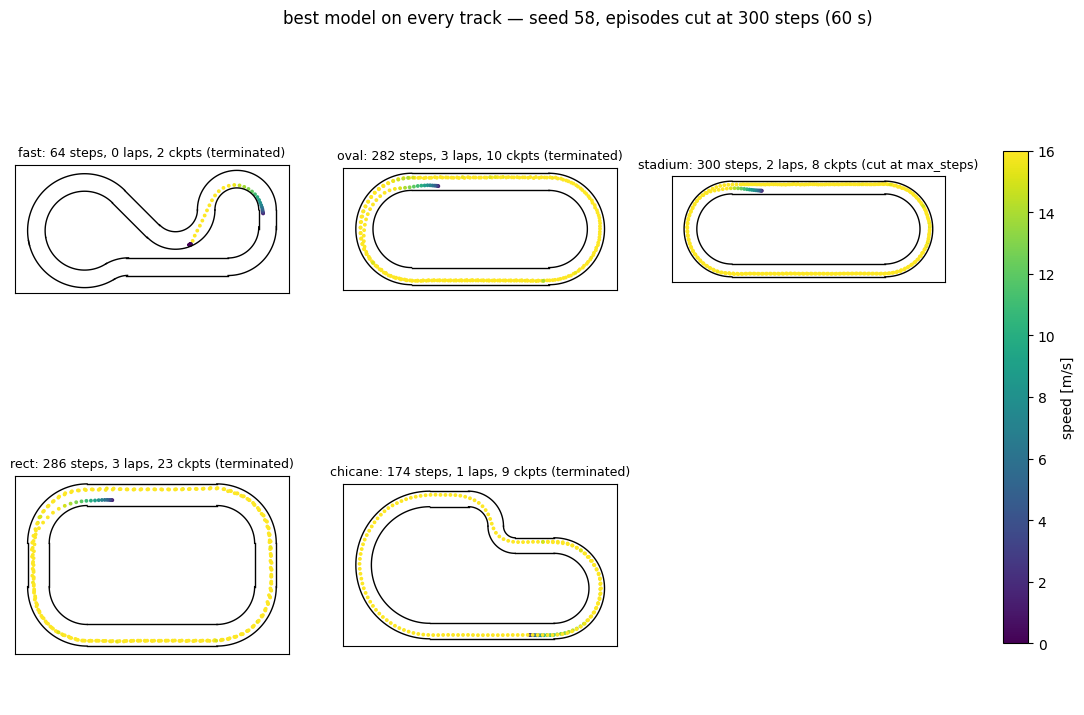

In [51]:
import matplotlib.pyplot as plt

ALL_TRACKS = ("fast", "oval", "stadium", "rect", "chicane")

def run_and_trace(model, config, seed, max_steps=None):
    """Drive one deterministic episode (no rendering); return the driven
    path, per-step speeds, the corridor wall polylines and episode stats."""
    tenv = gym.make(ENV_ID, config=config)
    obs, _ = tenv.reset(seed=seed)
    u = tenv.unwrapped
    xs, ys, vs = [], [], []
    terminated = truncated = False
    while not (terminated or truncated) and (max_steps is None or len(xs) < max_steps):
        action, _ = model.predict(obs[np.newaxis], deterministic=True)
        obs, reward, terminated, truncated, _ = tenv.step(action[0])
        xs.append(float(u.vehicle.position[0]))
        ys.append(float(u.vehicle.position[1]))
        vs.append(float(u.vehicle.speed))
        if len(xs) % 100 == 0:
            print(f"  ...{len(xs)} steps, {u.lap_count} laps so far", flush=True)
    stats = dict(track=u.active_track, laps=u.lap_count, ckpts=u.checkpoint_count,
                 steps=len(xs),
                 end="terminated" if terminated
                     else ("time limit" if truncated else "cut at max_steps"))
    walls = []                       # only the corridor's OUTER edges are walls
    graph = u.road.network.graph
    for _from in graph:
        for _to in graph[_from]:
            lanes = graph[_from][_to]
            for k, lane in enumerate(lanes):
                s = np.linspace(0, lane.length, max(2, int(lane.length)))
                lats = ([-lane.width / 2] if k == 0 else []) + \
                       ([lane.width / 2] if k == len(lanes) - 1 else [])
                for lat in lats:
                    walls.append(np.array([lane.position(si, lat) for si in s]))
    tenv.close()
    return np.array(xs), np.array(ys), np.array(vs), walls, stats

# One episode PER TRACK — traces are kept for the drawing video below.
plot_traces = {}
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sc = None
for ax, track_name in zip(axes.ravel(), ALL_TRACKS):
    cfg = rec_config.copy()
    cfg["track"] = track_name
    print(f"tracing '{track_name}' ...", flush=True)
    xs, ys, vs, walls, stats = run_and_trace(
        trained_model, cfg, seed=best_episode["seed"], max_steps=300)
    plot_traces[track_name] = (xs, ys, vs, walls, stats)
    for pts in walls:
        ax.plot(pts[:, 0], pts[:, 1], color="k", lw=1.0)
    sc = ax.scatter(xs, ys, c=vs, s=3, cmap="viridis",
                    vmin=0, vmax=cfg["speed_limit"])
    ax.set_aspect("equal"); ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{stats['track']}: {stats['steps']} steps, {stats['laps']} laps, "
                 f"{stats['ckpts']} ckpts ({stats['end']})", fontsize=9)
axes.ravel()[-1].axis("off")          # 6th panel unused
fig.colorbar(sc, ax=axes.ravel().tolist(), label="speed [m/s]", shrink=0.8)
fig.suptitle(f"best model on every track — seed {best_episode['seed']}, "
             f"episodes cut at 300 steps (60 s)")
fig.savefig(VIDEO_DIR / "trajectory_all_tracks.png", dpi=120, bbox_inches="tight")
print(f"saved -> {VIDEO_DIR / 'trajectory_all_tracks.png'}")
plt.show()


In [52]:
# ── Trajectory plots as a VIDEO of their drawing process — all tracks ──
# Replays how the grid above is generated: on every track panel the red
# car marker advances through the SAME deterministic episode (reusing the
# traces collected by the plot cell — no new inference) while the
# speed-coloured trail grows behind it. Saved as one mp4, shown inline.
# Works headless — no pygame/render backend needed, only ffmpeg.
import base64 as _tb64
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML as _tHTML, display as _tdisplay

try:
    import imageio_ffmpeg
    plt.rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()
except ImportError:
    pass   # a system ffmpeg on PATH also works

FPS, STRIDE = 15, 2      # stride=2 -> 10x realtime at the 5 Hz decision rate

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
panels = []
for ax, track_name in zip(axes.ravel(), ALL_TRACKS):
    xs, ys, vs, walls, stats = plot_traces[track_name]
    for pts in walls:
        ax.plot(pts[:, 0], pts[:, 1], color="k", lw=1.0)
    trail = ax.scatter([], [], c=[], s=3, cmap="viridis",
                       vmin=0, vmax=rec_config["speed_limit"])
    car, = ax.plot([], [], "o", color="red", ms=6, zorder=5)
    ax.set_aspect("equal"); ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    panels.append((ax, trail, car, track_name, xs, ys, vs, stats))
axes.ravel()[-1].axis("off")
fig.colorbar(panels[0][1], ax=axes.ravel().tolist(), label="speed [m/s]", shrink=0.8)

longest = max(len(p[4]) for p in panels)
frames = int(np.ceil(longest / STRIDE))

def _update(frame):
    changed = []
    for ax, trail, car, track_name, xs, ys, vs, stats in panels:
        n = min((frame + 1) * STRIDE, len(xs))
        trail.set_offsets(np.column_stack([xs[:n], ys[:n]]))
        trail.set_array(vs[:n])
        car.set_data([xs[n - 1]], [ys[n - 1]])
        ax.set_title(f"{track_name}: step {n}/{len(xs)} — {stats['laps']} laps, "
                     f"{stats['ckpts']} ckpts", fontsize=9)
        changed += [trail, car]
    return changed

anim = FuncAnimation(fig, _update, frames=frames, blit=False)
save_to = VIDEO_DIR / "trajectory_all_tracks_drawing.mp4"
anim.save(save_to, writer=FFMpegWriter(fps=FPS))
plt.close(fig)
print(f"saved -> {save_to}  ({frames} frames @ {FPS} fps, "
      f"{frames / FPS:.0f} s of video)")
b64 = _tb64.b64encode(Path(save_to).read_bytes()).decode("ascii")
_tdisplay(_tHTML(f'<video width="900" controls muted loop>'
                 f'<source src="data:video/mp4;base64,{b64}" '
                 f'type="video/mp4"></video>'))


saved -> c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\trajectory_all_tracks_drawing.mp4  (150 frames @ 15 fps, 10 s of video)


## Display the Exported Video

In [46]:
def show_video(video_path, width=720):
    """Embed an exported mp4 directly in the notebook."""
    video_path = Path(video_path)
    video_bytes = video_path.read_bytes()
    encoded = base64.b64encode(video_bytes).decode("ascii")
    display(HTML(f"""
    <video width="{width}" controls>
      <source src="data:video/mp4;base64,{encoded}" type="video/mp4">
    </video>
    """))

if best_video_path is not None:
    show_video(best_video_path)
else:
    print("No video file was found. Check that moviepy/ffmpeg are installed and rerun the recording cell.")


## record video env

In [47]:
from stable_baselines3.common.vec_env import VecVideoRecorder
def record_video(
    model_path: str | Path,
    video_dir:  str | Path,
    n_episodes: int  = 3,
    video_length: int = 300,   # steps per video, match your episode duration
):
    """
    Load trained model and record n_episodes to mp4.
    Completely separate from training — no interaction with train_env.
    """
    video_dir = Path(video_dir)
    video_dir.mkdir(parents=True, exist_ok=True)

    # Load model — device doesn't matter for inference, cpu is fine
    model = PPO.load(str(model_path), device="cpu")

    # Cap the episode to the recorded window: video_length steps at
    # policy_frequency (5 Hz). Default duration is 800 s = 4,000 steps,
    # which kept the loop running long after the recording stopped.
    rec_cfg = RacetrackFast.default_config().copy()
    rec_cfg["duration"] = video_length / rec_cfg["policy_frequency"]

    # Create a fresh env with rgb_array — NEVER reuse train_env here
    # rgb_array must be set at gym.make time; you cannot switch after creation
    record_env = DummyVecEnv([
        lambda: gym.make(ENV_ID, config=rec_cfg, render_mode="rgb_array")
    ])

    # Wrap with recorder — saves an mp4 every `video_length` steps
    record_env = VecVideoRecorder(
        record_env,
        video_folder = str(video_dir),
        record_video_trigger = lambda step: step == 0,  # start immediately
        video_length = video_length,
        name_prefix  = "racetrack_policy",
    )

    obs = record_env.reset()
    for episode in range(n_episodes):
        done  = False
        total = 0.0
        steps = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, info = record_env.step(action)
            total += float(reward[0])
            steps += 1

        print(f"Episode {episode+1}: {steps} steps, return={total:.2f}")
        obs = record_env.reset()

    record_env.close()
    print(f"Videos saved to {video_dir}")

In [48]:
def record_video_manual(
    model_path:  str | Path,
    output_path: str | Path,
    n_episodes:  int   = 1,
    fps:         int   = 15,    # match simulation_frequency
    resolution:  tuple = (600, 600),
):
    try:
        import cv2
    except ImportError:
        raise ImportError("pip install opencv-python")

    model  = PPO.load(str(model_path), device="cpu")
    output = Path(output_path)
    output.parent.mkdir(parents=True, exist_ok=True)

    cfg = RacetrackFast.default_config().copy()
    cfg["screen_width"]  = resolution[0]
    cfg["screen_height"] = resolution[1]

    # rgb_array must be at construction time — cannot change later
    env = gym.make(ENV_ID, config=cfg, render_mode="rgb_array")

    # OpenCV VideoWriter — mp4v codec is widely compatible
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = None

    for episode in range(n_episodes):
        obs, _ = env.reset()
        done = truncated = False
        total = 0.0

        while not (done or truncated):
            # Render BEFORE step so frame shows the state the policy saw
            frame = env.render()   # [H, W, 3] uint8 RGB

            if writer is None:
                h, w = frame.shape[:2]
                writer = cv2.VideoWriter(str(output), fourcc, fps, (w, h))

            # OpenCV uses BGR; convert from RGB
            writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

            action, _ = model.predict(obs[np.newaxis], deterministic=True)
            obs, reward, done, truncated, info = env.step(action[0])
            total += float(reward)

        print(f"Episode {episode+1}: return={total:.2f}")

    env.close()
    if writer:
        writer.release()
    print(f"Saved: {output}")

In [49]:
record_video(
    model_path  = BEST_MODEL_DIR / "phase2" / "best_model.zip",
    video_dir   = str(VIDEO_DIR),
    n_episodes  = 3,
    video_length= 300,
)

Episode 1: 89 steps, return=61.16
MoviePy - Building video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\racetrack_policy-step-0-to-step-300.mp4.
MoviePy - Writing video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\racetrack_policy-step-0-to-step-300.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\racetrack_policy-step-0-to-step-300.mp4
Episode 2: 94 steps, return=66.34
MoviePy - Building video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\racetrack_policy-step-89-to-step-389.mp4.
MoviePy - Writing video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\racetrack_policy-step-89-to-step-389.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\racetrack_policy-step-89-to-step-389.mp4
Saving video to c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\racetrack_policy-step-183-to-step-483.mp4
MoviePy - Building video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\racetrack_policy-step-183-to-step-483.mp4.
MoviePy - Writing video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\racetrack_policy-step-183-to-step-483.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\racetrack_policy-step-183-to-step-483.mp4
Episode 3: 300 steps, return=173.29
MoviePy - Building video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\racetrack_policy-step-483-to-step-783.mp4.
MoviePy - Writing video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\racetrack_policy-step-483-to-step-783.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos\racetrack_policy-step-483-to-step-783.mp4
Videos saved to c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_gen_cnn\videos


## Optional: TensorBoard

Run this cell while training or after training to inspect reward, loss, entropy, KL, and evaluation curves.

In [50]:
# Uncomment these lines in an interactive notebook session.

